# Federated Generative Learning

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sys.path.insert(0, '..')
from UC1Utils import prepare_data, ensure_data, CSV_MAIN

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

PALETTE = {
    'Not readmitted':    '#4C72B0',
    'Readmitted (<30d)': '#DD8452',
}

# ── Shared hyperparameters — loaded from FedAvg tuning ────────────────────────
# These must match FedAvg exactly: same architecture, same training regime.
# Generated by 02_UC1_Federated.ipynb Cell 14.
FEDERATED_DIR = '../federated_data'
_hp_path = os.path.join(FEDERATED_DIR, 'fl_hyperparams.json')
if not os.path.exists(_hp_path):
    raise FileNotFoundError(
        f'Federated hyperparameters not found at {_hp_path}.\n'
        f'Run 02_UC1_Federated.ipynb first and ensure Cell 14 saves fl_hyperparams.json.'
    )
with open(_hp_path) as f:
    _hp = json.load(f)

HIDDEN_DIM = _hp['hidden_dim']
DROPOUT    = _hp['dropout']
LR         = _hp['lr']
BATCH_SIZE = _hp['batch_size']

print(f'Loaded shared hyperparameters from {_hp_path}:')
print(f'  hidden_dim : {HIDDEN_DIM}')
print(f'  dropout    : {DROPOUT:.4f}')
print(f'  lr         : {LR:.6f}')
print(f'  batch_size : {BATCH_SIZE}')

# ── FedGen-specific hyperparameters ───────────────────────────────────────────
N_CLIENTS    = 5
FL_ROUNDS    = 30
LOCAL_EPOCHS = 10
PATIENCE     = 5
NOISE_DIM    = 16    # noise vector dimension fed to generator
GEN_LR       = 1e-3  # generator learning rate (separate from model LR)
GEN_STEPS    = 10    # generator update steps per round
LAMBDA_PROTO = 0.1   # prototype constraint weight (ablated in experiments)
SEEDS        = [42, 123, 7]
ALPHA_SWEEP  = [0.5, 1.0, 5.0]

RESULTS_DIR     = 'results'
CENTRALIZED_AUC = 0.658

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs('figures',   exist_ok=True)

# ── Derived quantities ─────────────────────────────────────────────────────────
# latent_dim is the output dimension of the feature extractor = HIDDEN_DIM // 4.
# The generator must output vectors of exactly this dimension.
latent_dim = HIDDEN_DIM // 4
print(f'\nDerived latent_dim: {latent_dim}  (HIDDEN_DIM // 4 = {HIDDEN_DIM} // 4)')

# ── Load full dataset for latent space analysis ────────────────────────────────
ensure_data()
X, y, groups, feature_names = prepare_data(CSV_MAIN, verbose=True)
input_dim = X.shape[1]
print(f'Input dim: {input_dim}  |  Latent dim: {latent_dim}')

Device: cuda
Loaded shared hyperparameters from ../federated_data/fl_hyperparams.json:
  hidden_dim : 512
  dropout    : 0.1803
  lr         : 0.009296
  batch_size : 256

Derived latent_dim: 128  (HIDDEN_DIM // 4 = 512 // 4)
✓ CSV files already present, skipping extraction.
dropna removed 1518 rows (1.53%) — likely from unmapped admission_type/source IDs
Dataset shape after cleaning: (97825, 101)
Class distribution:
readmitted_binary
0    86618
1    11207
Name: count, dtype: int64
Imbalance ratio: 7.73:1  (positive rate: 11.46%)
Input dim: 99  |  Latent dim: 128


In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler


def load_clients(alpha, output_dir, n_clients):
    """Load pre-generated client data (produced by 02_FedAvg)."""
    alpha_dir = os.path.join(output_dir, f'alpha_{alpha}')
    clients   = {}
    for i in range(n_clients):
        d = os.path.join(alpha_dir, f'client_{i}')
        clients[i] = {
            'X_train': torch.tensor(np.load(f'{d}/X_train.npy'), dtype=torch.float32),
            'y_train': torch.tensor(np.load(f'{d}/y_train.npy'), dtype=torch.long),
            'X_val':   torch.tensor(np.load(f'{d}/X_val.npy'),   dtype=torch.float32),
            'y_val':   torch.tensor(np.load(f'{d}/y_val.npy'),   dtype=torch.long),
            'X_test':  torch.tensor(np.load(f'{d}/X_test.npy'),  dtype=torch.float32),
            'y_test':  torch.tensor(np.load(f'{d}/y_test.npy'),  dtype=torch.long),
        }
        n_pos = clients[i]['y_train'].sum().item()
        if n_pos == 0:
            raise ValueError(
                f'client_{i} at α={alpha} has zero positive training examples. '
                f'Re-run 02_FedAvg/02_UC1_Federated.ipynb to regenerate data.'
            )
    return clients


print('load_clients() defined. Data is generated by 02_FedAvg/02_UC1_Federated.ipynb.')


load_clients() defined. Data is generated by 02_FedAvg/02_UC1_Federated.ipynb.


## Latent Space Analysis: Where the Generator Actually Operates

With `hidden_dim = 512`, your MLP architecture is:

```
Feature extractor θ^f:  99 → 512 → 256 → 128   (LayerNorm + ReLU + Dropout)
Predictor head θ^p:      128 → 2
```

The FedGen generator operates in **Z = ℝ¹²⁸** (the 128-dimensional penultimate layer).
Here we load the saved centralized MLP and inspect the class-conditional geometry of
the latent space — this is what the generator is trying to approximate.

If the two classes are well-separated in latent space, the generator has a clearly
defined target distribution. If they overlap significantly, the generator's task is
harder and the inductive bias is weaker.

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4), nn.ReLU(), nn.Dropout(dropout),
        )
        self.predictor = nn.Linear(hidden_dim // 4, output_dim)

    def forward(self, x):
        return self.predictor(self.feature_extractor(x))

    def encode(self, x):
        return self.feature_extractor(x)


# ── Load centralized checkpoint ───────────────────────────────────────────────
CKPT_PATH = '../01_Centralized/models/mlp_centralized.pt'
print(f'\nAttempting to load centralized checkpoint from: {os.path.exists(CKPT_PATH)}')
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    hidden_dim = ckpt.get('hidden_dim', 256)
    dropout    = ckpt.get('dropout',    0.3)
    scaler     = ckpt.get('scaler',     StandardScaler())

    model = MLP(input_dim=X.shape[1], hidden_dim=hidden_dim, dropout=dropout).to(device)

    # Remap state_dict keys: original model uses 'net.*', new uses 'feature_extractor.*' / 'predictor.*'
    orig_sd = ckpt['model_state_dict']
    new_sd  = {}
    fe_layers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  # indices in original net.Sequential
    # Map net.0..net.11 → feature_extractor, net.12 → predictor
    for k, v in orig_sd.items():
        if k.startswith('net.'):
            idx = int(k.split('.')[1])
            rest = '.'.join(k.split('.')[2:])
            if idx < 12:  # feature extractor layers
                new_sd[f'feature_extractor.{idx}.{rest}'] = v
            else:
                new_sd[f'predictor.{rest}'] = v
        else:
            new_sd[k] = v

    model.load_state_dict(new_sd, strict=False)
    model.eval()

    # ── Extract latent representations ────────────────────────────────────────
    X_scaled = scaler.transform(X) if hasattr(scaler, 'mean_') else X
    X_t = torch.tensor(X_scaled, dtype=torch.float32)

    latent_vecs = []
    with torch.no_grad():
        loader = DataLoader(TensorDataset(X_t), batch_size=2048)
        for (xb,) in loader:
            latent_vecs.append(model.encode(xb.to(device)).cpu().numpy())
    Z = np.concatenate(latent_vecs, axis=0)

    print(f'Latent space shape: {Z.shape}  (n_samples × latent_dim)')
    LATENT_LOADED = True
else:
    print(f'Checkpoint not found at {CKPT_PATH}.')
    print('Skipping latent space analysis. Run this after training the centralized model.')
    LATENT_LOADED = False


Attempting to load centralized checkpoint from: True
Latent space shape: (97825, 128)  (n_samples × latent_dim)


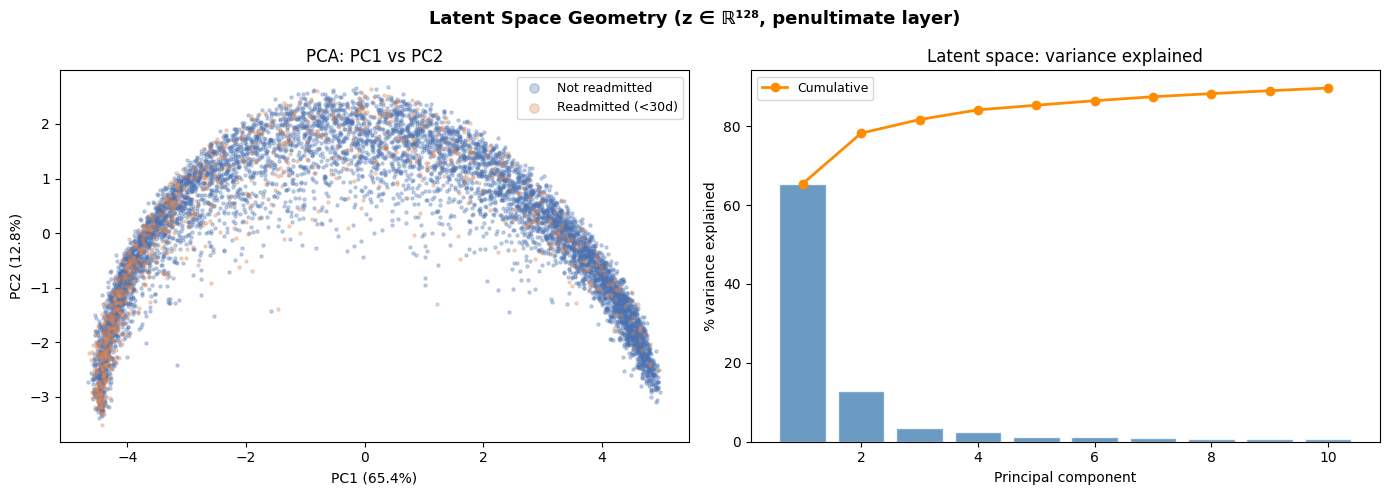


Latent space class-conditional statistics:
  Class 0 — mean norm: 5.784 | mean intra-class dist (sample): 3.407
  Class 1 — mean norm: 5.892 | mean intra-class dist (sample): 3.617
  Inter-class centroid distance: 2.031
  Latent dimension: 128

  → These are the prototype centroids z̄_y that a constrained generator should stay near.


In [4]:
if LATENT_LOADED:
    # ── PCA of latent space, colored by class ─────────────────────────────────
    pca = PCA(n_components=10)
    Z_pca = pca.fit_transform(Z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Latent Space Geometry (z ∈ ℝ¹²⁸, penultimate layer)',
                 fontweight='bold', fontsize=13)

    # Subsample for visualization
    idx_sub = np.random.default_rng(SEED).choice(len(Z), size=min(8000, len(Z)), replace=False)
    Z_sub   = Z_pca[idx_sub]
    y_sub   = y[idx_sub]

    # PC1 vs PC2
    for label, (name, color) in zip([0, 1], PALETTE.items()):
        mask = y_sub == label
        axes[0].scatter(Z_sub[mask, 0], Z_sub[mask, 1],
                        c=color, alpha=0.3, s=5, label=name, rasterized=True)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title('PCA: PC1 vs PC2')
    axes[0].legend(markerscale=3, fontsize=9)

    # Explained variance
    axes[1].bar(range(1, 11), pca.explained_variance_ratio_ * 100,
                color='steelblue', alpha=0.8, edgecolor='white')
    axes[1].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100,
                 'o-', color='darkorange', linewidth=2, markersize=6, label='Cumulative')
    axes[1].set_xlabel('Principal component')
    axes[1].set_ylabel('% variance explained')
    axes[1].set_title('Latent space: variance explained')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('figures/09_latent_space_pca.png', bbox_inches='tight')
    plt.show()

    # ── Per-class statistics in latent space ──────────────────────────────────
    Z0 = Z[y == 0]
    Z1 = Z[y == 1]

    print('\nLatent space class-conditional statistics:')
    print(f'  Class 0 — mean norm: {np.linalg.norm(Z0.mean(0)):.3f} | '
          f'mean intra-class dist (sample): {np.mean(np.linalg.norm(Z0[:500] - Z0[:500].mean(0), axis=1)):.3f}')
    print(f'  Class 1 — mean norm: {np.linalg.norm(Z1.mean(0)):.3f} | '
          f'mean intra-class dist (sample): {np.mean(np.linalg.norm(Z1[:500] - Z1[:500].mean(0), axis=1)):.3f}')
    inter_dist = np.linalg.norm(Z0.mean(0) - Z1.mean(0))
    print(f'  Inter-class centroid distance: {inter_dist:.3f}')
    print(f'  Latent dimension: {Z.shape[1]}')
    print(f'\n  → These are the prototype centroids z̄_y that a constrained generator should stay near.')

## Generator Constraint: Prototype Regularization

Based on the latent space analysis above, we define the per-class centroids $\bar{z}_y$
that can serve as the anchor for prototype regularization.

The modified generator loss with constraint is:

$$J(w) := \underbrace{\mathbb{E}_{y,z}\left[\ell\left(\sigma\left(\frac{1}{K}\sum_k g(z;\theta^p_k)\right), y\right)\right]}_{\text{ensemble classification loss}} + \underbrace{\lambda \cdot \mathbb{E}_{y, z\sim G_w(\cdot|y)} \left[ \|z - \bar{z}_y\|^2 \right]}_{\text{prototype regularization}}$$

This ensures generated representations stay near the latent region occupied by real
patients of each class. The hyperparameter $\lambda$ controls the trade-off between
ensemble consensus (original objective) and distributional fidelity (constraint).

The main idea is that since the statistics can not be trully trusted in order to make real clinical vectors, they must be generated close to real ones, like reducing the noise from it.

Prototype centroids (z̄_y) computed:
  z̄_{y=0}: shape=(128,), norm=5.784, mean std=0.288
  z̄_{y=1}: shape=(128,), norm=5.892, mean std=0.271

Mean intra-class variance: class0=0.123, class1=0.109
Suggested λ starting point: ~0.1 (ablate over [0.0, 0.01, 0.1, 1.0])


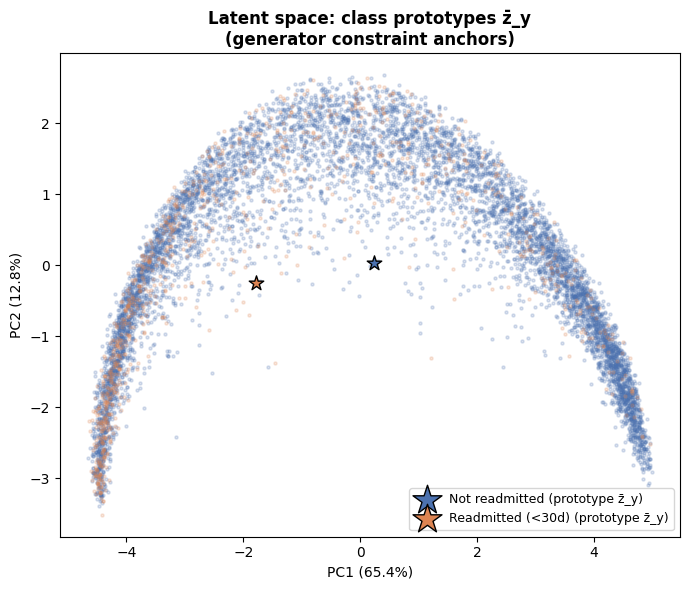


Prototypes saved to prototypes_class0.npy / prototypes_class1.npy


In [5]:
if LATENT_LOADED:
    # Compute and save per-class prototypes
    prototypes = {
        0: Z[y == 0].mean(axis=0),  # z̄_{y=0}
        1: Z[y == 1].mean(axis=0),  # z̄_{y=1}
    }
    prototype_stds = {
        0: Z[y == 0].std(axis=0),
        1: Z[y == 1].std(axis=0),
    }

    print('Prototype centroids (z̄_y) computed:')
    for cls in [0, 1]:
        print(f'  z̄_{{y={cls}}}: shape={prototypes[cls].shape}, '
              f'norm={np.linalg.norm(prototypes[cls]):.3f}, '
              f'mean std={prototype_stds[cls].mean():.3f}')

    # Suggested λ: a fraction of the typical intra-class variance
    # so the constraint is soft but meaningful
    intra_var_0 = np.mean(np.var(Z[y == 0], axis=0))
    intra_var_1 = np.mean(np.var(Z[y == 1], axis=0))
    suggested_lambda_scale = 0.1  # 10% of intra-class variance
    print(f'\nMean intra-class variance: class0={intra_var_0:.3f}, class1={intra_var_1:.3f}')
    print(f'Suggested λ starting point: ~{suggested_lambda_scale} '
          f'(ablate over [0.0, 0.01, 0.1, 1.0])')

    # Visualize prototype + 1-std ellipse in PCA space
    fig, ax = plt.subplots(figsize=(7, 6))
    for label, (name, color) in zip([0, 1], PALETTE.items()):
        mask = y_sub == label
        ax.scatter(Z_sub[mask, 0], Z_sub[mask, 1],
                   c=color, alpha=0.2, s=5, rasterized=True)
        # Project prototype into PCA space
        proto_pca = pca.transform(prototypes[label].reshape(1, -1))[0]
        ax.scatter(*proto_pca[:2], c=color, s=120, marker='*',
                   edgecolors='black', linewidth=1, zorder=5,
                   label=f'{name} (prototype z̄_y)')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('Latent space: class prototypes z̄_y\n'
                 '(generator constraint anchors)', fontweight='bold')
    ax.legend(markerscale=2, fontsize=9)
    plt.tight_layout()
    plt.savefig('figures/10_latent_prototypes.png', bbox_inches='tight')
    plt.show()

    np.save('prototypes_class0.npy', prototypes[0])
    np.save('prototypes_class1.npy', prototypes[1])
    print('\nPrototypes saved to prototypes_class0.npy / prototypes_class1.npy')
else:
    print('Latent analysis skipped — train centralized model first.')

## KD-gen: Knowledge Distillation with Generative Model

Adapted from Salami et al. (arXiv:2405.05140v1) for UC1 binary classification.

### Key idea
Standard FedAvg suffers from **client drift** under non-IID data (α=0.5 Dirichlet partitioning).
KD-gen addresses this by introducing a lightweight generator G_ω shared across clients that
produces synthetic latent vectors Ẑ, used as an inductive bias during local training.

### What changes vs FedAvg

| | FedAvg | KD-gen |
|---|---|---|
| Communicated per round | Full model θ | Predictor **g_r** + generator **ω** |
| Feature extractor g_f | Aggregated on server | **Stays local** per client |
| Synthetic data | None | G_ω(y, ε) → Ẑ used in KD loss |
| Rationale for small G_ω | — | Tabular binary task; g_f already maps 99 features to ℝ¹²⁸ |

### Algorithm 1 (adapted for classification)
```
for round t:
  server  → clients : g_r weights, generator ω
  each client k:
    load global g_r  (g_f stays local)
    sample Ŷ ~ U{0,1},  ε ~ N(0,I)
    Ẑ = G_ω(Ŷ, ε)           ← frozen, no grad
    for each local epoch:
      step 1 – full model update:  L_real = CE(g_r(g_f(X)), Y)
      step 2 – g_r only update :   L_kd   = CE(g_r(Ẑ), Ŷ)
    send g_r state + per-class latent distribution p^(k) to server
  server:
    FedAvg on g_r  (weighted by client sample sizes)
    GMM update:  p̂ ← weighted mean of {p^(k)}
    generator update:  min CE(ensemble(G_ω(Ŷ',ε')), Ŷ') + λ·||G_ω(Ŷ',ε') - z̄_{Ŷ'}||²
```

In [6]:
class Generator(nn.Module):
    """
    Lightweight generator G_ω: (y, ε) → ẑ ∈ ℝ^latent_dim.

    Takes a class label (embedded) and a noise vector, outputs a latent
    vector that the ensemble of predictor heads should classify as class y.
    ~4,900 parameters — small by design.
    """
    def __init__(self, latent_dim=128, noise_dim=16, n_classes=2, embed_dim=4):
        super().__init__()
        self.embed = nn.Embedding(n_classes, embed_dim)
        self.net   = nn.Sequential(
            nn.Linear(embed_dim + noise_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
        )

    def forward(self, y, eps):
        return self.net(torch.cat([self.embed(y), eps], dim=1))


# ── MLP with split architecture ────────────────────────────────────────────────
# Needed for partial sharing: feature_extractor stays local, predictor is shared.
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4), nn.ReLU(), nn.Dropout(dropout),
        )
        self.predictor = nn.Linear(hidden_dim // 4, output_dim)

    def forward(self, x):
        return self.predictor(self.feature_extractor(x))

    def encode(self, x):
        return self.feature_extractor(x)
    

# ── Parameter counts and communication cost ───────────────────────────────────
_m = MLP(input_dim, HIDDEN_DIM, dropout=DROPOUT)
_g = Generator(latent_dim, NOISE_DIM)

n_full      = sum(p.numel() for p in _m.parameters())
n_predictor = sum(p.numel() for p in _m.predictor.parameters())
n_gen       = sum(p.numel() for p in _g.parameters())
del _m, _g

B = 4  # bytes per float32 parameter

print(f'{"Component":<25} {"Params":>10} {"KB":>8}')
print('-' * 46)
print(f'{"Full MLP":<25} {n_full:>10,} {n_full*B/1024:>8.1f}')
print(f'{"  Feature extractor":<25} {n_full - n_predictor:>10,} {(n_full-n_predictor)*B/1024:>8.1f}')
print(f'{"  Predictor head":<25} {n_predictor:>10,} {n_predictor*B/1024:>8.1f}')
print(f'{"Generator":<25} {n_gen:>10,} {n_gen*B/1024:>8.1f}')

# ── Communication cost per round (all N_CLIENTS combined) ─────────────────────
#
# FedAvg full:
#   Each client downloads global model + uploads local model = 2 × n_full params
#
# FedGen full:
#   Each client downloads global model + uploads local model + downloads generator
#   = 2 × n_full + n_gen params
#   → Nearly identical to FedAvg full; generator adds < 1% overhead.
#   The thesis point: FedGen full does NOT save communication — it trades
#   accuracy-under-heterogeneity, not bandwidth.
#
# FedGen partial:
#   Feature extractor stays local — never communicated.
#   Each client downloads predictor + uploads predictor + downloads generator
#   = 2 × n_predictor + n_gen params
#   → Large savings: predictor is only 2 linear weights vs full model.

bytes_fedavg_full   = 2 * n_full      * B * N_CLIENTS
bytes_fedgen_full   = (2 * n_full   + n_gen) * B * N_CLIENTS
bytes_fedgen_partial = (2 * n_predictor + n_gen) * B * N_CLIENTS

print(f'\n{"Variant":<25} {"MB/round":>10} {"vs FedAvg full":>16}')
print('-' * 54)
print(f'{"FedAvg full":<25} {bytes_fedavg_full/1024**2:>10.2f} {"(baseline)":>16}')
print(f'{"FedGen full":<25} {bytes_fedgen_full/1024**2:>10.2f} '
      f'{bytes_fedgen_full/bytes_fedavg_full:>15.2f}×')
print(f'{"FedGen partial":<25} {bytes_fedgen_partial/1024**2:>10.2f} '
      f'{bytes_fedgen_partial/bytes_fedavg_full:>14.3f}×')

print(f'\n→ FedGen full ≈ FedAvg full in MB: the generator adds negligible overhead.')
print(f'→ FedGen partial achieves a {bytes_fedavg_full/bytes_fedgen_partial:.0f}× '
      f'reduction by keeping the feature extractor local.')
print(f'→ The Pareto comparison of interest is FedAvg full vs FedGen partial:')
print(f'  does KD recover accuracy lost from partial sharing, at {bytes_fedavg_full/bytes_fedgen_partial:.0f}× lower cost?')

Component                     Params       KB
----------------------------------------------
Full MLP                     217,474    849.5
  Feature extractor          217,216    848.5
  Predictor head                 258      1.0
Generator                      4,904     19.2

Variant                     MB/round   vs FedAvg full
------------------------------------------------------
FedAvg full                     8.30       (baseline)
FedGen full                     8.39            1.01×
FedGen partial                  0.10          0.012×

→ FedGen full ≈ FedAvg full in MB: the generator adds negligible overhead.
→ FedGen partial achieves a 80× reduction by keeping the feature extractor local.
→ The Pareto comparison of interest is FedAvg full vs FedGen partial:
  does KD recover accuracy lost from partial sharing, at 80× lower cost?


In [7]:
# ── Load client data from the shared federated_data directory ─────────────────
# Data was generated by 02_FedAvg/02_UC1_Federated.ipynb.
# ALPHA is set per iteration in the sweep loop (Cell 12).
# This cell loads for the default ALPHA_SWEEP[0] for inspection.

ALPHA = ALPHA_SWEEP[0]  # default; overridden in sweep loop

clients   = load_clients(ALPHA, FEDERATED_DIR, N_CLIENTS)
input_dim = clients[0]['X_train'].shape[1]

for i in range(N_CLIENTS):
    n     = len(clients[i]['y_train'])
    pos   = clients[i]['y_train'].float().mean().item() * 100
    n_pos = int(clients[i]['y_train'].sum().item())
    print(f'client_{i}: {n:,} train  pos_rate={pos:.1f}%  n_pos={n_pos}')

print(f'\nInput dim: {input_dim}  |  Latent dim: {latent_dim}')


client_0: 5,345 train  pos_rate=1.3%  n_pos=69
client_1: 14,630 train  pos_rate=1.6%  n_pos=232
client_2: 34,247 train  pos_rate=17.9%  n_pos=6143
client_3: 9,736 train  pos_rate=8.8%  n_pos=857
client_4: 2,540 train  pos_rate=13.7%  n_pos=347

Input dim: 99  |  Latent dim: 128


In [8]:
# ── Shared helpers ─────────────────────────────────────────────────────────────

def make_criterion(y_numpy, device):
    classes = np.unique(y_numpy)
    if len(classes) < 2:
        return nn.CrossEntropyLoss()
    cw = compute_class_weight('balanced', classes=classes, y=y_numpy)
    return nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )


def fed_avg_state(state_dicts, sample_counts):
    """Weighted average of state dicts (works for full model or predictor-only)."""
    total = sum(sample_counts)
    return {
        k: sum(sd[k] * (sample_counts[i] / total)
               for i, sd in enumerate(state_dicts))
        for k in state_dicts[0].keys()
    }


def _aggregate_prototypes(client_stats):
    """
    Weighted aggregation of per-client per-class centroids.

    Each client returns per_class_stats[cls] = {'mean': ..., 'std': ..., 'n': int}.
    Server computes weighted mean of means and pooled std (√Σ w_i σ_i²).

    Returns dict: global_prototypes[cls] = {'mean': array, 'std': array}
    """
    global_prototypes = {}
    for cls in [0, 1]:
        cls_means, cls_vars, cls_ns = [], [], []
        for stats in client_stats:
            if cls in stats:
                cls_means.append(stats[cls]['mean'])
                cls_vars.append(stats[cls]['std'] ** 2)
                cls_ns.append(stats[cls]['n'])
        if not cls_means:
            continue
        total_cls = sum(cls_ns)
        weights   = [n / total_cls for n in cls_ns]
        global_prototypes[cls] = {
            'mean': sum(w * m for w, m in zip(weights, cls_means)),
            'std':  np.sqrt(sum(w * v for w, v in zip(weights, cls_vars))) + 1e-8,
        }
    return global_prototypes


def _compute_local_prototypes(model, X_train, y_train, device):
    """
    Compute per-class centroids in the client's current latent space.
    Called at the end of local training — uses the final encoder state,
    which is the actual latent space the client operates in.
    """
    model.eval()
    with torch.no_grad():
        Z_all = model.encode(X_train.to(device)).cpu().numpy()
    y_np = y_train.numpy()
    per_class_stats = {}
    for cls in [0, 1]:
        mask = y_np == cls
        if mask.sum() > 0:
            Z_cls = Z_all[mask]
            per_class_stats[cls] = {
                'mean': Z_cls.mean(axis=0),
                'std':  Z_cls.std(axis=0) + 1e-8,
                'n':    int(mask.sum()),
            }
    return per_class_stats


def update_generator(generator, gr_states, global_prototypes, device):
    """
    Server-side generator update.

    Minimises:
      E[mean_k softmax(G(y,ε)·W_k^T + b_k), y]   ← ensemble CE (mean of probs)
      + λ · E[‖G(y,ε) − z̄_y‖²]                   ← prototype constraint (L2 for now)

    Ensemble uses mean of softmax PROBABILITIES across K heads, not softmax of
    averaged logits. These are not equivalent — the former is a proper probability
    ensemble; the latter is a fictitious single head that no client possesses.
    """
    all_w = [sd['weight'].to(device) for sd in gr_states]
    all_b = [sd['bias'].to(device)   for sd in gr_states]

    proto_t = {
        cls: torch.tensor(v['mean'], dtype=torch.float32, device=device)
        for cls, v in global_prototypes.items()
    }

    opt = torch.optim.Adam(generator.parameters(), lr=GEN_LR)
    generator.train()

    for _ in range(GEN_STEPS):
        opt.zero_grad()
        half  = 64
        y_gen = torch.cat([
            torch.zeros(half, dtype=torch.long, device=device),
            torch.ones( half, dtype=torch.long, device=device),
        ])
        eps   = torch.randn(len(y_gen), NOISE_DIM, device=device)
        Z_gen = generator(y_gen, eps)

        # Ensemble: mean of softmax probabilities across K predictor heads
        probs = torch.stack([
            torch.softmax(Z_gen @ w.T + b, dim=1)
            for w, b in zip(all_w, all_b)
        ]).mean(0)                                          # (batch, n_classes)
        loss_ce = -(torch.log(probs[range(len(y_gen)), y_gen] + 1e-8)).mean()

        # Prototype constraint — plain L2 (standardized distance fix follows)
        proto_tgt = torch.stack([proto_t[int(yy.item())] for yy in y_gen])
        loss_p    = ((Z_gen - proto_tgt) ** 2).mean()

        (loss_ce + LAMBDA_PROTO * loss_p).backward()
        opt.step()

    generator.eval()


# ── FedGen partial: feature extractor stays local, predictor shared ────────────
def local_train_fedgen_partial(model, generator, X_train, y_train,
                                X_val, y_val, device):
    loader      = DataLoader(TensorDataset(X_train, y_train),
                             batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    criterion_r  = make_criterion(y_train.numpy(), device)
    criterion_kd = nn.CrossEntropyLoss()
    opt_full = torch.optim.Adam(model.parameters(),           lr=LR)
    opt_gr   = torch.optim.Adam(model.predictor.parameters(), lr=LR)

    best_val_auc  = 0.0
    best_gr_state = {k: v.clone() for k, v in model.predictor.state_dict().items()}

    for _ in range(LOCAL_EPOCHS):
        model.train()

        # Fresh synthetic batch each epoch — different noise realization every time.
        # This is intentional: the generator is a stochastic map (y, ε) → z̃,
        # and reusing the same z̃ across epochs collapses the KD signal to a
        # fixed target, eliminating the diversity the noise dimension provides.
        n_syn = min(BATCH_SIZE, len(X_train))
        with torch.no_grad():
            y_hat = torch.randint(0, 2, (n_syn,), device=device)
            eps   = torch.randn(n_syn, NOISE_DIM, device=device)
            Z_hat = generator(y_hat, eps)

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            # Step 1: real data — update full model
            model.zero_grad()
            criterion_r(model(xb), yb).backward()
            opt_full.step()
            # Step 2: KD — update predictor only via synthetic latent vectors
            model.predictor.zero_grad()
            criterion_kd(model.predictor(Z_hat), y_hat).backward()
            opt_gr.step()

        model.eval()
        with torch.no_grad():
            vp = torch.softmax(model(X_val.to(device)), dim=1)[:, 1].cpu().numpy()
        if len(np.unique(y_val.numpy())) > 1:
            auc = roc_auc_score(y_val.numpy(), vp)
            if auc > best_val_auc:
                best_val_auc  = auc
                best_gr_state = {k: v.clone()
                                 for k, v in model.predictor.state_dict().items()}

    # Compute per-class centroids in this client's latent space.
    # Uses the final encoder state — the feature extractor is never reset between
    # rounds, so this reflects the actual latent geometry after local adaptation.
    per_class_stats = _compute_local_prototypes(model, X_train, y_train, device)

    return best_gr_state, len(X_train), per_class_stats


# ── FedGen full: entire model shared, generator provides KD ───────────────────
def local_train_fedgen_full(model, generator, X_train, y_train,
                             X_val, y_val, device):
    loader      = DataLoader(TensorDataset(X_train, y_train),
                             batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    criterion_r  = make_criterion(y_train.numpy(), device)
    criterion_kd = nn.CrossEntropyLoss()
    opt_full = torch.optim.Adam(model.parameters(),           lr=LR)
    # Separate persistent optimizer for KD step — maintains momentum across batches.
    # The original code created a new Adam inside the batch loop, discarding all
    # accumulated momentum state at every batch, which is incorrect.
    opt_gr   = torch.optim.Adam(model.predictor.parameters(), lr=LR)

    best_val_auc = 0.0
    best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    for _ in range(LOCAL_EPOCHS):
        model.train()

        # Fresh synthetic batch each epoch — same reason as partial variant above
        n_syn = min(BATCH_SIZE, len(X_train))
        with torch.no_grad():
            y_hat = torch.randint(0, 2, (n_syn,), device=device)
            eps   = torch.randn(n_syn, NOISE_DIM, device=device)
            Z_hat = generator(y_hat, eps)

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            # Step 1: real data — full model
            opt_full.zero_grad()
            criterion_r(model(xb), yb).backward()
            opt_full.step()
            # Step 2: KD — predictor only
            opt_gr.zero_grad()
            criterion_kd(model.predictor(Z_hat), y_hat).backward()
            opt_gr.step()

        model.eval()
        with torch.no_grad():
            vp = torch.softmax(model(X_val.to(device)), dim=1)[:, 1].cpu().numpy()
        if len(np.unique(y_val.numpy())) > 1:
            auc = roc_auc_score(y_val.numpy(), vp)
            if auc > best_val_auc:
                best_val_auc = auc
                best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    per_class_stats = _compute_local_prototypes(model, X_train, y_train, device)

    return best_state, len(X_train), per_class_stats


print('Training functions defined.')

Training functions defined.


In [9]:
re_train = True

def evaluate_fedgen(model, clients, use_local_encoders=False, local_models=None):
    model.eval()
    all_proba, all_y = [], []
    per_client = {}
    with torch.no_grad():
        for i, c in clients.items():
            enc   = local_models[i] if use_local_encoders else model
            z     = enc.encode(c['X_test'].to(device))
            proba = torch.softmax(model.predictor(z), dim=1)[:, 1].cpu().numpy()
            y_test = c['y_test'].numpy()
            all_proba.append(proba)
            all_y.append(y_test)
            if len(np.unique(y_test)) > 1:
                per_client[str(i)] = float(roc_auc_score(y_test, proba))
    return float(roc_auc_score(np.concatenate(all_y), np.concatenate(all_proba))), per_client


def save_result(variant_dir, variant, test_auc, per_client, history, cumul_mb):
    os.makedirs(variant_dir, exist_ok=True)
    path = os.path.join(variant_dir, f'{variant}.json')
    with open(path, 'w') as f:
        json.dump({'test_auc': test_auc, 'per_client': per_client,
                   'history': history, 'cumul_mb': cumul_mb}, f, indent=2)
    print(f'  Saved → {path}  (test_auc={test_auc:.4f})')


# ── FedGen partial ─────────────────────────────────────────────────────────────
def run_fedgen_partial(clients, input_dim, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    global_model = MLP(input_dim, HIDDEN_DIM, dropout=DROPOUT).to(device)
    generator_   = Generator(latent_dim, NOISE_DIM).to(device)
    local_models = {
        i: MLP(input_dim, HIDDEN_DIM, dropout=DROPOUT).to(device)
        for i in range(N_CLIENTS)
    }
    for i in range(N_CLIENTS):
        local_models[i].load_state_dict(global_model.state_dict())

    n_pred = sum(p.numel() for p in global_model.predictor.parameters())
    n_gen  = sum(p.numel() for p in generator_.parameters())
    # Download predictor + upload predictor + download generator, per client per round.
    # Per-class centroid upload (2 × latent_dim floats) is negligible and omitted.
    bytes_per_round = (2 * n_pred + n_gen) * 4 * N_CLIENTS

    best_val_auc, best_gr_state, best_gen_state, no_improve = 0.0, None, None, 0
    history, cumul_mb, total_bytes = [], [], 0

    for fl_round in range(FL_ROUNDS):
        gr_states, counts, client_stats = [], [], []

        for i in range(N_CLIENTS):
            local_models[i].predictor.load_state_dict(
                global_model.predictor.state_dict()
            )
            sd, n, stats = local_train_fedgen_partial(
                local_models[i], generator_,
                clients[i]['X_train'], clients[i]['y_train'],
                clients[i]['X_val'],   clients[i]['y_val'], device
            )
            gr_states.append(sd)
            counts.append(n)
            client_stats.append(stats)

        global_model.predictor.load_state_dict(fed_avg_state(gr_states, counts))

        # Aggregate per-class centroids from all clients this round.
        # Each client computed centroids in its own latent space after local training.
        # Server takes weighted mean of means and pooled std.
        global_prototypes = _aggregate_prototypes(client_stats)
        update_generator(generator_, gr_states, global_prototypes, device)

        total_bytes += bytes_per_round

        global_model.eval()
        vp, vy, tp, ty = [], [], [], []
        with torch.no_grad():
            for i in range(N_CLIENTS):
                z_v = local_models[i].encode(clients[i]['X_val'].to(device))
                z_t = local_models[i].encode(clients[i]['X_test'].to(device))
                vp.append(torch.softmax(global_model.predictor(z_v), dim=1)[:,1].cpu().numpy())
                vy.append(clients[i]['y_val'].numpy())
                tp.append(torch.softmax(global_model.predictor(z_t), dim=1)[:,1].cpu().numpy())
                ty.append(clients[i]['y_test'].numpy())

        val_auc  = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        test_auc = roc_auc_score(np.concatenate(ty), np.concatenate(tp))
        history.append({'val': val_auc, 'test': test_auc})
        cumul_mb.append(total_bytes / (1024 ** 2))
        print(f'  [partial] R{fl_round+1:02d}: val={val_auc:.4f} test={test_auc:.4f} '
              f'cumul={cumul_mb[-1]:.2f}MB')

        if val_auc > best_val_auc:
            best_val_auc   = val_auc
            best_gr_state  = {k: v.clone()
                              for k, v in global_model.predictor.state_dict().items()}
            best_gen_state = {k: v.clone() for k, v in generator_.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at round {fl_round+1}.')
                break

    global_model.predictor.load_state_dict(best_gr_state)
    global_auc, per_client = evaluate_fedgen(global_model, clients,
                                             use_local_encoders=True,
                                             local_models=local_models)
    return global_auc, per_client, history, cumul_mb


# ── FedGen full ────────────────────────────────────────────────────────────────
def run_fedgen_full(clients, input_dim, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    global_model = MLP(input_dim, HIDDEN_DIM, dropout=DROPOUT).to(device)
    generator_   = Generator(latent_dim, NOISE_DIM).to(device)

    n_full = sum(p.numel() for p in global_model.parameters())
    n_gen  = sum(p.numel() for p in generator_.parameters())
    # Full model both ways + generator download.
    # This is intentionally ≈ FedAvg full — the generator adds < 1% overhead.
    # FedGen full trades accuracy-under-heterogeneity, not bandwidth.
    bytes_per_round = (2 * n_full + n_gen) * 4 * N_CLIENTS

    best_val_auc, best_state, best_gen_state, no_improve = 0.0, None, None, 0
    history, cumul_mb, total_bytes = [], [], 0

    for fl_round in range(FL_ROUNDS):
        state_dicts, gr_states, counts, client_stats = [], [], [], []

        for i in range(N_CLIENTS):
            local = MLP(input_dim, HIDDEN_DIM, dropout=DROPOUT).to(device)
            local.load_state_dict(global_model.state_dict())
            sd, n, stats = local_train_fedgen_full(
                local, generator_,
                clients[i]['X_train'], clients[i]['y_train'],
                clients[i]['X_val'],   clients[i]['y_val'], device
            )
            state_dicts.append(sd)
            gr_states.append({k: v.clone()
                               for k, v in local.predictor.state_dict().items()})
            counts.append(n)
            client_stats.append(stats)

        global_model.load_state_dict(fed_avg_state(state_dicts, counts))

        global_prototypes = _aggregate_prototypes(client_stats)
        update_generator(generator_, gr_states, global_prototypes, device)

        total_bytes += bytes_per_round

        global_model.eval()
        vp, vy, tp, ty = [], [], [], []
        with torch.no_grad():
            for i in range(N_CLIENTS):
                vp.append(torch.softmax(global_model(clients[i]['X_val'].to(device)),
                                        dim=1)[:,1].cpu().numpy())
                vy.append(clients[i]['y_val'].numpy())
                tp.append(torch.softmax(global_model(clients[i]['X_test'].to(device)),
                                        dim=1)[:,1].cpu().numpy())
                ty.append(clients[i]['y_test'].numpy())

        val_auc  = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        test_auc = roc_auc_score(np.concatenate(ty), np.concatenate(tp))
        history.append({'val': val_auc, 'test': test_auc})
        cumul_mb.append(total_bytes / (1024 ** 2))
        print(f'  [full] R{fl_round+1:02d}: val={val_auc:.4f} test={test_auc:.4f} '
              f'cumul={cumul_mb[-1]:.2f}MB')

        if val_auc > best_val_auc:
            best_val_auc   = val_auc
            best_state     = {k: v.clone() for k, v in global_model.state_dict().items()}
            best_gen_state = {k: v.clone() for k, v in generator_.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at round {fl_round+1}.')
                break

    global_model.load_state_dict(best_state)
    global_auc, per_client = evaluate_fedgen(global_model, clients)
    return global_auc, per_client, history, cumul_mb


# ── Outer sweep: all alphas × seeds × variants ────────────────────────────────
# Note: prototypes are no longer passed as arguments — they are computed
# round-by-round inside each run function from client latent statistics.
for alpha in ALPHA_SWEEP:
    for seed in SEEDS:
        r_dir        = os.path.join(RESULTS_DIR, f'alpha_{alpha}', f'seed_{seed}')
        partial_path = os.path.join(r_dir, 'fedgen_partial.json')
        full_path    = os.path.join(r_dir, 'fedgen_full.json')

        if os.path.exists(partial_path) and os.path.exists(full_path) and not re_train:
            print(f'α={alpha} seed={seed}: already done, skipping.')
            continue

        print(f'\n{"="*60}')
        print(f'FedGen  α={alpha}  seed={seed}')
        print(f'{"="*60}')

        clients   = load_clients(alpha, FEDERATED_DIR, N_CLIENTS)
        input_dim = clients[0]['X_train'].shape[1]

        if not os.path.exists(partial_path) or re_train:
            print('\n--- fedgen_partial ---')
            auc, pc, hist, cmb = run_fedgen_partial(clients, input_dim, seed)
            save_result(r_dir, 'fedgen_partial', auc, pc, hist, cmb)

        if not os.path.exists(full_path) or re_train:
            print('\n--- fedgen_full ---')
            auc, pc, hist, cmb = run_fedgen_full(clients, input_dim, seed)
            save_result(r_dir, 'fedgen_full', auc, pc, hist, cmb)

print('\nAll FedGen experiments complete.')


FedGen  α=0.5  seed=42

--- fedgen_partial ---
  [partial] R01: val=0.7014 test=0.6768 cumul=0.10MB
  [partial] R02: val=0.7165 test=0.6932 cumul=0.21MB
  [partial] R03: val=0.6832 test=0.6640 cumul=0.31MB
  [partial] R04: val=0.6964 test=0.6796 cumul=0.41MB
  [partial] R05: val=0.6930 test=0.6722 cumul=0.52MB
  [partial] R06: val=0.6951 test=0.6803 cumul=0.62MB
  [partial] R07: val=0.6951 test=0.6797 cumul=0.72MB
  Early stopping at round 7.
  Saved → results/alpha_0.5/seed_42/fedgen_partial.json  (test_auc=0.6431)

--- fedgen_full ---
  [full] R01: val=0.6317 test=0.6198 cumul=8.39MB
  [full] R02: val=0.6323 test=0.6205 cumul=16.78MB
  [full] R03: val=0.6328 test=0.6205 cumul=25.17MB
  [full] R04: val=0.6319 test=0.6175 cumul=33.56MB
  [full] R05: val=0.6284 test=0.6139 cumul=41.95MB
  [full] R06: val=0.6227 test=0.6100 cumul=50.34MB
  [full] R07: val=0.6268 test=0.6103 cumul=58.73MB
  [full] R08: val=0.6236 test=0.6066 cumul=67.12MB
  Early stopping at round 8.
  Saved → results/al

In [10]:
# ── Summary: print saved FedGen results ──────────────────────────────────────
import glob
print(f'{"Alpha":>6}  {"Seed":>6}  {"Variant":<20}  {"Test AUC":>9}  {"Rounds":>7}')
print('-' * 60)
for path in sorted(glob.glob(f'{RESULTS_DIR}/alpha_*/seed_*/*.json')):
    r = json.load(open(path))
    parts = path.replace(RESULTS_DIR + '/', '').replace('.json', '').split('/')
    alpha_s, seed_s, variant = parts
    print(f'{alpha_s.replace("alpha_",""):>6}  '
          f'{seed_s.replace("seed_",""):>6}  '
          f'{variant:<20}  '
          f'{r["test_auc"]:>9.4f}  '
          f'{len(r["history"]):>7}')


 Alpha    Seed  Variant                Test AUC   Rounds
------------------------------------------------------------
   0.5     123  fedgen_full              0.6196        9
   0.5     123  fedgen_partial           0.6901       10
   0.5      42  fedgen_full              0.6205        8
   0.5      42  fedgen_partial           0.6431        7
   0.5       7  fedgen_full              0.6124        8
   0.5       7  fedgen_partial           0.6828       14
   1.0     123  fedgen_full              0.6195        8
   1.0     123  fedgen_partial           0.5959        6
   1.0      42  fedgen_full              0.6157        9
   1.0      42  fedgen_partial           0.5568       13
   1.0       7  fedgen_full              0.6158        8
   1.0       7  fedgen_partial           0.6365       20
   5.0     123  fedgen_full              0.6382        8
   5.0     123  fedgen_partial           0.6109       10
   5.0      42  fedgen_full              0.6396       13
   5.0      42  fedgen_part